# Machine Learning in Python - Project 

Due Friday, Apr 10th by 4 pm.

*Include contributors names here*

## Setup

*Install any packages here, define any functions if neeed, and load data*

In [1]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn

In [2]:
# Load data  
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


# Introduction

*This section should include a brief introduction to the task and the data (assume this is a report you are delivering to a professional body (e.g. UNICEF)).*

*Briefly outline the approaches being used and the conclusions that you are able to draw.*

# Exploratory Data Analysis and Feature Engineering

*Include a detailed discussion of the data with a particular emphasis on the features of the data that are relevant for the subsequent modeling. Including visualizations of the data is strongly encouraged - all code and plots must also be described in the write up. Think carefully about whether each plot needs to be included in your final draft and the appropriate type of plot and summary for each variable type - your report should include figures but they should be as focused and impactful as possible.*

*You should also split your data into training and testing sets, ideally before you look to much into the features and relationships with the target.*

*Additionally, this section should also motivate and describe any preprocessing / feature engineering of the data. Pipelines should be used and feature engineering steps that are be performed as part of an sklearn pipeline can be mentioned here but should be implemented in the following section.*

*All code and figures should be accompanied by text that provides an overview / context to what is being done or presented.*

In [2]:
import pandas as pd
import numpy as np

# read data
df = pd.read_csv("unicef_malawi_cleaned_full.csv")

# Transform into binary variable
df["child_depression"] = df["FCF26"].map({
    "No": 0,
    "YES": 1
})

# check results
print(df[["FCF26", "child_depression"]].head())
print(df["child_depression"].value_counts(dropna=False))
df = df.dropna(subset=["child_depression"]).copy()
print(df["child_depression"].isna().sum())
print(df.shape)


  FCF26  child_depression
0    No               0.0
1    No               0.0
2    No               0.0
3    No               0.0
4    No               0.0
child_depression
1.0    7131
0.0    5905
NaN     126
Name: count, dtype: int64
0
(13036, 91)


=== Numeric variable summary ===
   variable  missing_pct  n_nonmissing  zero_pct_among_nonmissing  skewness
12    CDEAD     0.000000         13036                   0.743326  2.733973
3       CL2     0.000000         13036                   0.681574  0.779602
5      CL12     0.000000         13036                   0.150583 -1.954229
11    CSURV     0.000000         13036                   0.016646  0.513009
2    wscore     0.000000         13036                   0.000077  1.828476
0       CB3     0.000000         13036                   0.000000  0.333122
7       WB4     0.021402         12757                   0.000000  0.110841
8      WB6B     0.021939          1561                   1.000000  0.000000
10      LS2     0.026312         12693                   0.093437 -0.003475
1      CB5B     0.048251           851                   1.000000  0.000000
13      WS4     0.133553         11075                   0.000000  9.175581
6      CL13     0.150583         11071                 

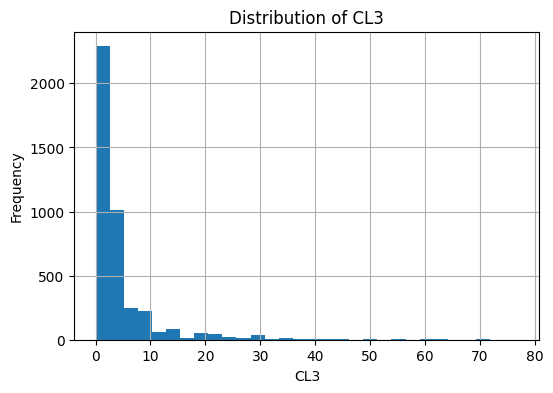

CL3 skewness = 4.108, zero_pct = 0.244


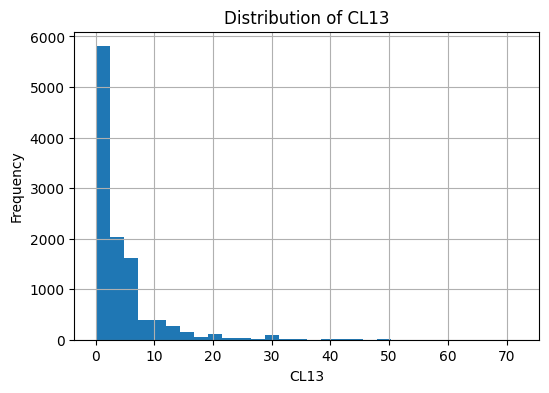

CL13 skewness = 3.572, zero_pct = 0.242


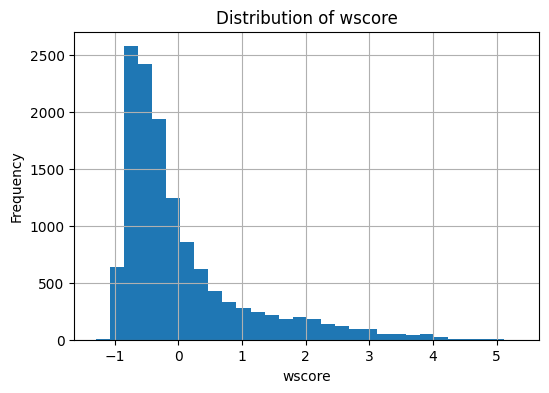

wscore skewness = 1.828, zero_pct = 0.000


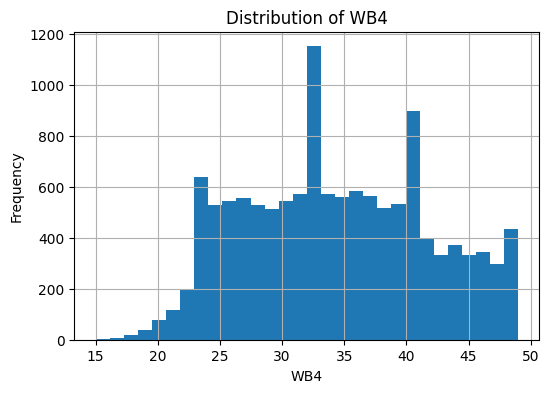

WB4 skewness = 0.111, zero_pct = 0.000


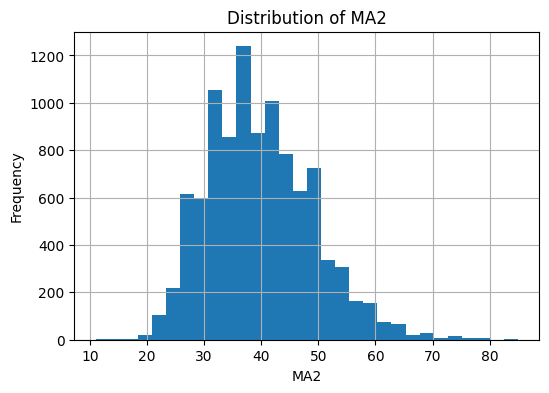

MA2 skewness = 0.568, zero_pct = 0.000


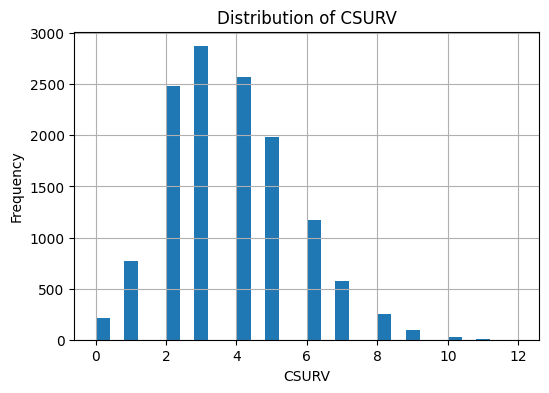

CSURV skewness = 0.513, zero_pct = 0.017


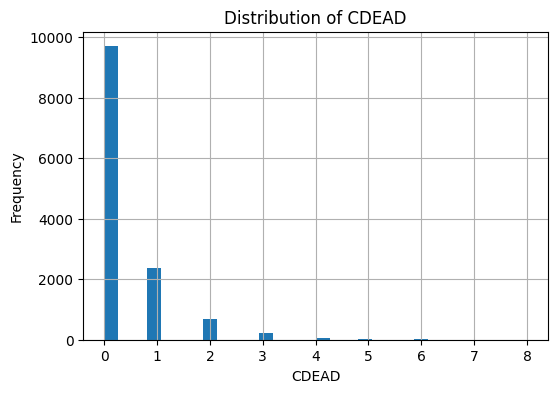

CDEAD skewness = 2.734, zero_pct = 0.743

=== Transformation log ===
   original_variable used_variable            transformation
0                CB3           CB3                       raw
1                CB4           CB4  raw_non_numeric_or_empty
2               CB5A          CB5A  raw_non_numeric_or_empty
3               CB5B          CB5B                       raw
4                CB7           CB7  raw_non_numeric_or_empty
..               ...           ...                       ...
77               WS7           WS7  raw_non_numeric_or_empty
78              WS11          WS11  raw_non_numeric_or_empty
79              WS14          WS14  raw_non_numeric_or_empty
80              WS15          WS15  raw_non_numeric_or_empty
81               HW5           HW5  raw_non_numeric_or_empty

[82 rows x 3 columns]

=== Transformed blocks ===
child_background : ['CB3', 'CB4', 'CB5A', 'CB5B', 'CB7', 'CB11', 'HH6', 'HH7', 'HL4', 'ethnicity', 'wscore_log1p']
child_labour : ['CL2', 'CL3', 'CL

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 0. 基础设置
# =========================================================

# 直接沿用你当前 notebook 里的 df
# 假设你已经生成过 child_depression，并删掉了其缺失值
# 例如：
# df["child_depression"] = (
#     df["FCF26"].astype(str).str.strip().str.upper().map({"NO": 0, "YES": 1})
# )
# df = df.dropna(subset=["child_depression"]).copy()

missing_thresh = 0.30   # 缺失率阈值：30%
corr_thresh = 0.70      # 高相关性阈值：|Spearman rho| >= 0.70
max_vars_per_block = 4  # 每个区块最多保留4个变量

# 这些变量更像连续型/计数型，若非零值较多且右偏，可考虑 log(x+1)
continuous_score_candidates = [
    "wscore", "WB4", "MA2", "CSURV", "CDEAD"
]

# 这些变量是小时数/计数，若 0 值很多，更适合转成 ordered categories
zero_heavy_candidates = ["CL3", "CL13"]

# =========================================================
# 1. 定义区块
# =========================================================

blocks = {
    "child_background": [
        "CB3","CB4","CB5A","CB5B","CB7","CB11",
        "HH6","HH7","HL4","ethnicity","wscore"
    ],
    
    "child_labour": [
        "CL2","CL3","CL12","CL13"
    ],
    
    "child_discipline": [
        "FCD2A","FCD2B","FCD2C","FCD2D","FCD2E",
        "FCD2F","FCD2G","FCD2H","FCD2I","FCD2J",
        "FCD2K","FCD5"
    ],
    
    "mother_background": [
        "WB4","WB5","WB6A","WB6B","WB14"
    ],
    
    "domestic_violence": [
        "DV1A","DV1B","DV1C","DV1D","DV1E"
    ],
    
    "victimization": [
        "VT1","VT9","VT20","VT21",
        "VT22A","VT22B","VT22C","VT22D","VT22E","VT22F","VT22X"
    ],
    
    "marriage_union": [
        "MSTATUS","MA2","MA3"
    ],
    
    "adult_functioning": [
        "disability","AF10","AF11","AF12"
    ],
    
    "tobacco_alcohol": [
        "TA1","TA14"
    ],
    
    "life_satisfaction": [
        "LS1","LS2","LS3","LS4"
    ],
    
    "fertility": [
        "CSURV","CDEAD"
    ],
    
    "household_characteristics": [
        "HC4","HC5","HC8","HC11","HC12",
        "HC13","HC14","HC15","HC17","HC19"
    ],
    
    "insecticide_nets": [
        "TN1"
    ],
    
    "water_sanitation": [
        "WS1","WS3","WS4","WS7","WS11","WS14","WS15"
    ],
    
    "handwashing": [
        "HW5"
    ]
}

# =========================================================
# 2. 一些辅助函数
# =========================================================

def clean_special_missing(series):
    s = series.copy()
    s = s.replace([
        "DK", "NO RESPONSE", "DK / NO OPINION",
        "DON'T KNOW", "MISSING", "NA", "N/A", "", " "
    ], np.nan)
    return s

def to_numeric_safe(series):
    return pd.to_numeric(clean_special_missing(series), errors="coerce")

def encode_for_corr(series):
    """
    为 Spearman 相关性分析做编码：
    - 数值变量直接保留
    - 二元 YES/NO 映射为 1/0
    - 其他分类变量 factorize
    """
    s = clean_special_missing(series)

    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    s = s.astype(str).str.strip().str.upper()
    s = s.replace({"NAN": np.nan})

    binary_map = {
        "YES": 1, "NO": 0,
        "Y": 1, "N": 0,
        "TRUE": 1, "FALSE": 0
    }

    unique_vals = set(s.dropna().unique())
    if len(unique_vals) > 0 and unique_vals.issubset(set(binary_map.keys())):
        return s.map(binary_map)

    codes, uniques = pd.factorize(s, sort=True)
    return pd.Series(codes, index=s.index).replace(-1, np.nan)

def summarize_numeric_variable(series, name):
    s = to_numeric_safe(series)
    non_missing = s.dropna()
    if len(non_missing) == 0:
        return {
            "variable": name,
            "missing_pct": series.isna().mean(),
            "n_nonmissing": 0,
            "zero_pct_among_nonmissing": np.nan,
            "skewness": np.nan
        }
    return {
        "variable": name,
        "missing_pct": series.isna().mean(),
        "n_nonmissing": len(non_missing),
        "zero_pct_among_nonmissing": (non_missing == 0).mean(),
        "skewness": non_missing.skew()
    }

def make_ordered_from_zero_heavy(series, new_name):
    """
    适合像 CL3 / CL13 这种 0 值很多、右偏明显的变量。
    分箱规则：
    0 -> 0
    正值部分按三分位分成 1/2/3
    """
    s = to_numeric_safe(series)
    out = pd.Series(np.nan, index=s.index, dtype="float")
    
    out[s == 0] = 0
    
    pos = s[s > 0]
    if len(pos) >= 4 and pos.nunique() >= 3:
        try:
            out.loc[pos.index] = pd.qcut(pos, q=3, labels=[1, 2, 3], duplicates="drop").astype(float)
        except:
            # 兜底：手动分箱
            q1, q2 = pos.quantile([1/3, 2/3])
            out.loc[(s > 0) & (s <= q1)] = 1
            out.loc[(s > q1) & (s <= q2)] = 2
            out.loc[(s > q2)] = 3
    else:
        # 若正值太少，做简单二分
        out.loc[s > 0] = 1
    
    return out.rename(new_name)

def make_log_transform(series, new_name):
    s = to_numeric_safe(series)
    # 只对 >=0 的值做 log1p；负值转缺失
    s = s.where(s >= 0, np.nan)
    return np.log1p(s).rename(new_name)

def choose_representation(var, df):
    """
    决定一个变量最终用于分析的形式：
    - 原始变量
    - ordered 变量
    - log1p 变量
    """
    s_num = to_numeric_safe(df[var])
    non_missing = s_num.dropna()

    # 若无法视为数值，就保留原始变量
    if len(non_missing) == 0:
        return var, df[var], "raw_non_numeric_or_empty"

    zero_pct = (non_missing == 0).mean()
    skewness = non_missing.skew()

    # 0值很多的 hours/count 类变量 -> ordered
    if var in zero_heavy_candidates and zero_pct >= 0.40:
        new_name = f"{var}_ord"
        return new_name, make_ordered_from_zero_heavy(df[var], new_name), "ordered_from_zero_heavy"

    # 更连续的 score/count -> log1p
    if var in continuous_score_candidates and (skewness is not np.nan) and abs(skewness) >= 1:
        new_name = f"{var}_log1p"
        return new_name, make_log_transform(df[var], new_name), "log1p"

    # 否则保留原始变量
    return var, df[var], "raw"

def select_block_variables(data, vars_list, missing_thresh=0.30, corr_thresh=0.70, max_keep=4):
    """
    每个区块：
    1) 先删缺失率 > 阈值
    2) 计算 Spearman 绝对相关矩阵
    3) 按缺失率从低到高贪心保留，保证与已选变量的相关性低
    4) 最多保留 max_keep 个
    """
    existing_vars = [v for v in vars_list if v in data.columns]
    if len(existing_vars) == 0:
        return {
            "selected": [],
            "dropped_high_missing": [],
            "dropped_high_corr": [],
            "missing_table": pd.DataFrame(),
            "corr_matrix": pd.DataFrame()
        }

    missing_pct = data[existing_vars].isna().mean()
    missing_table = pd.DataFrame({
        "variable": existing_vars,
        "missing_pct": missing_pct.values
    }).sort_values("missing_pct")

    candidate_vars = missing_pct[missing_pct <= missing_thresh].sort_values().index.tolist()
    dropped_high_missing = [v for v in existing_vars if v not in candidate_vars]

    if len(candidate_vars) == 0:
        return {
            "selected": [],
            "dropped_high_missing": dropped_high_missing,
            "dropped_high_corr": [],
            "missing_table": missing_table,
            "corr_matrix": pd.DataFrame()
        }

    encoded = pd.DataFrame({v: encode_for_corr(data[v]) for v in candidate_vars})
    corr = encoded.corr(method="spearman").abs()

    selected = []
    dropped_high_corr = []

    for v in candidate_vars:
        if len(selected) == 0:
            selected.append(v)
        else:
            max_corr = corr.loc[v, selected].max()
            if pd.isna(max_corr) or max_corr < corr_thresh:
                selected.append(v)
            else:
                dropped_high_corr.append(v)

        if len(selected) >= max_keep:
            break

    # 没被选中且也不是 high missing 的，其实可视为“因排序/上限未入选”
    remaining_not_selected = [v for v in candidate_vars if v not in selected and v not in dropped_high_corr]

    return {
        "selected": selected,
        "dropped_high_missing": dropped_high_missing,
        "dropped_high_corr": dropped_high_corr,
        "not_selected_due_to_limit_or_order": remaining_not_selected,
        "missing_table": missing_table,
        "corr_matrix": corr
    }

# =========================================================
# 3. 检查所有“可数值化变量”的缺失值与分布
# =========================================================

all_block_vars = []
for vs in blocks.values():
    all_block_vars.extend(vs)
all_block_vars = list(dict.fromkeys([v for v in all_block_vars if v in df.columns]))

numeric_summary = []
for v in all_block_vars:
    s_num = to_numeric_safe(df[v])
    # 只把“至少有一部分能转为数值”的变量纳入 numeric summary
    if s_num.notna().sum() > 0:
        numeric_summary.append(summarize_numeric_variable(df[v], v))

numeric_summary_df = pd.DataFrame(numeric_summary).sort_values(
    by=["missing_pct", "zero_pct_among_nonmissing"],
    ascending=[True, False]
)

print("=== Numeric variable summary ===")
print(numeric_summary_df)

# =========================================================
# 4. 画出数值变量分布
# =========================================================

vars_to_plot = [v for v in zero_heavy_candidates + continuous_score_candidates if v in df.columns]

for v in vars_to_plot:
    s = to_numeric_safe(df[v]).dropna()
    if len(s) == 0:
        continue
    plt.figure(figsize=(6,4))
    s.hist(bins=30)
    plt.title(f"Distribution of {v}")
    plt.xlabel(v)
    plt.ylabel("Frequency")
    plt.show()
    print(f"{v} skewness = {s.skew():.3f}, zero_pct = {(s==0).mean():.3f}")

# =========================================================
# 5. 为变量选择最终表示形式
# =========================================================

transformation_log = []

analysis_df = df.copy()
representation_map = {}   # 原变量 -> 最终使用的变量名

for v in all_block_vars:
    new_name, new_series, trans_type = choose_representation(v, analysis_df)
    representation_map[v] = new_name
    
    if new_name != v:
        analysis_df[new_name] = new_series
    
    transformation_log.append({
        "original_variable": v,
        "used_variable": new_name,
        "transformation": trans_type
    })

transformation_log_df = pd.DataFrame(transformation_log)

print("\n=== Transformation log ===")
print(transformation_log_df)

# =========================================================
# 6. 用“转换后的变量”重建区块
# =========================================================

transformed_blocks = {}
for block_name, vars_list in blocks.items():
    transformed_blocks[block_name] = [
        representation_map[v] for v in vars_list if v in representation_map
    ]

print("\n=== Transformed blocks ===")
for k, v in transformed_blocks.items():
    print(k, ":", v)

# =========================================================
# 7. 分区块做相关性分析 + 变量筛选
# =========================================================

selection_results = {}

for block_name, vars_list in transformed_blocks.items():
    result = select_block_variables(
        data=analysis_df,
        vars_list=vars_list,
        missing_thresh=missing_thresh,
        corr_thresh=corr_thresh,
        max_keep=max_vars_per_block
    )
    selection_results[block_name] = result

    print("\n" + "="*80)
    print(f"BLOCK: {block_name}")
    print("="*80)
    print(f"Variables used in this block: {vars_list}")

    print("\nSelected variables:")
    print(result["selected"])

    print("\nDropped due to missingness > 30%:")
    print(result["dropped_high_missing"])

    print("\nDropped due to high correlation:")
    print(result["dropped_high_corr"])

    print("\nNot selected because of ordering / max 4 limit:")
    print(result.get("not_selected_due_to_limit_or_order", []))

    print("\nMissing table:")
    print(result["missing_table"])

    print("\nAbsolute Spearman correlation matrix:")
    print(result["corr_matrix"].round(2))

# =========================================================
# 8. 汇总最终选中的变量
# =========================================================

final_selected_vars = []
for block_name, result in selection_results.items():
    final_selected_vars.extend(result["selected"])

final_selected_vars = list(dict.fromkeys(final_selected_vars))

print("\n" + "="*80)
print("FINAL SELECTED VARIABLES")
print("="*80)
print(final_selected_vars)
print(f"\nTotal selected variables: {len(final_selected_vars)}")

# =========================================================
# 9. 输出每个区块最终选中的变量表
# =========================================================

selected_summary = pd.DataFrame({
    "block": list(selection_results.keys()),
    "selected_variables": [selection_results[b]["selected"] for b in selection_results.keys()],
    "n_selected": [len(selection_results[b]["selected"]) for b in selection_results.keys()]
})

print("\n=== Selected variables by block ===")
print(selected_summary)

# =========================================================
# 10. 生成最终建模数据
# =========================================================

model_df = analysis_df[final_selected_vars + ["child_depression"]].copy()

print("\n=== Final model_df shape ===")
print(model_df.shape)
print(model_df.head())

In [23]:
# 复制 transformation_log_df，避免改动原表
transformation_log_export = transformation_log_df.copy()

# 添加变化解释
transformation_log_export["change_explanation"] = transformation_log_export["transformation"].map({
    "raw": "No transformation was applied. The original variable was kept in its original form for screening and modelling.",
    "ordered": "The original numeric variable was converted into an ordered categorical variable because it had many zero values and a strongly skewed distribution. Zero values were kept as 0, and positive values were grouped into increasing ordered levels.",
    "log1p": "A log(x+1) transformation was applied because the variable was treated as a more continuous score/count variable with a right-skewed distribution. This transformation reduces skewness while preserving the ordering of values."
}).fillna(
    "Other transformation or no explanation specified."
)

# 可选：加一个更短的标签列
transformation_log_export["short_note"] = transformation_log_export["transformation"].map({
    "raw": "Original variable kept",
    "ordered": "Converted to ordered variable",
    "log1p": "Applied log(x+1)"
}).fillna("Other")

# 调整列顺序
transformation_log_export = transformation_log_export[
    ["original_variable", "used_variable", "transformation", "short_note", "change_explanation"]
]

# 输出为 CSV
transformation_log_export.to_csv("E:/PGT/MLP/transformation_log_with_explanations.csv", index=False)

# 查看结果
print(transformation_log_export)

   original_variable used_variable            transformation  \
0                CB3           CB3                       raw   
1                CB4           CB4  raw_non_numeric_or_empty   
2               CB5A          CB5A  raw_non_numeric_or_empty   
3               CB5B          CB5B                       raw   
4                CB7           CB7  raw_non_numeric_or_empty   
..               ...           ...                       ...   
77               WS7           WS7  raw_non_numeric_or_empty   
78              WS11          WS11  raw_non_numeric_or_empty   
79              WS14          WS14  raw_non_numeric_or_empty   
80              WS15          WS15  raw_non_numeric_or_empty   
81               HW5           HW5  raw_non_numeric_or_empty   

                short_note                                 change_explanation  
0   Original variable kept  No transformation was applied. The original va...  
1                    Other  Other transformation or no explanation spec

# Model Fitting and Tuning

*In this section you should detail and motivate your choice of model and describe the process used to refine, tune, and fit that model. You are encouraged to explore different models but you should NOT include a detailed narrative or code of all of these attempts. At most this section should very briefly mention the methods explored and why they were rejected - most of your effort should go into describing the final model you are using and your process for tuning and validating it.*

*This section should include the full implementation of your final model, including all necessary validation. As with figures, any included code must also be addressed in the text of the document.*

*You should also include a baseline model of your choice and provide a comparison of your model with the baseline model on the test data. You should briefly describe the baseline model considered.*

# Interpretation, Discussion & Conclusions

*In this section you should provide a general overview of your final model, its performance, and reliability. You should discuss what the implications of your model are in terms of the included features, estimated parameters and relationships, predictive performance, and anything else you think is relevant.*

*This should be written with a target audience of a government official, who understands the issues associated with mental health but may only have university level mathematics (not necessarily postgraduate statistics or machine learning). Your goal should be to highlight to this audience how your model can useful. You should also discuss potential limitations or directions of future improvement of your model.*

*Finally, you should include recommendations on factors that may increase the risk of depression, which may be useful for the government officials and health care workers to improve their understanding of the condition, and potentially assit in the development of effective social and health policies and interventions.*

*Keep in mind that a negative result, i.e. a model that does not work well predictively, that is well explained and justified in terms of why it failed will likely receive higher marks than a model with strong predictive performance but with poor or incorrect explanations / justifications.*

# Generative AI statement

*Include a statement on how generative AI was used in the project and report.*

# References

*Include references if any*

In [ ]:
# Run the following to render to PDF
!jupyter nbconvert --to pdf project.ipynb